# Questions
Which department has the highest employee attrition?

Does overtime increase the likelihood of employees leaving?

Is salary related to attrition?

Which age group leaves the most?

Does job satisfaction affect attrition?

Does environment satisfaction affect attrition?

Does longer tenure reduce attrition?

Which job roles experience the highest attrition?

Does marital status influence attrition?

Which combinations of factors are most associated with employees leaving?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.shape

(1470, 35)

In [7]:
df.index

RangeIndex(start=0, stop=1470, step=1)

In [8]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

### Selecting Required Columns

In [64]:
select = ['Age', 'Attrition','Department',
          'EnvironmentSatisfaction','MaritalStatus','JobRole',
          'JobSatisfaction','MonthlyIncome','OverTime','TotalWorkingYears','YearsAtCompany']

In [65]:
df = df[select]
df.shape

(1470, 11)

In [68]:
df.head()

,Age,Attrition,Department,EnvironmentSatisfaction,MaritalStatus,JobRole,JobSatisfaction,MonthlyIncome,OverTime,TotalWorkingYears,YearsAtCompany
0,41,Yes,Sales,2,Single,Sales Executive,4,5993,Yes,8,6
1,49,No,Research & Development,3,Married,Research Scientist,2,5130,No,10,10
2,37,Yes,Research & Development,4,Single,Laboratory Technician,3,2090,Yes,7,0
3,33,No,Research & Development,4,Married,Research Scientist,3,2909,Yes,8,8
4,27,No,Research & Development,1,Married,Laboratory Technician,2,3468,No,6,2


In [67]:
df.isnull().sum()

Age                        0
Attrition                  0
Department                 0
EnvironmentSatisfaction    0
MaritalStatus              0
JobRole                    0
JobSatisfaction            0
MonthlyIncome              0
OverTime                   0
TotalWorkingYears          0
YearsAtCompany             0
dtype: int64

In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df.value_counts().sum()

np.int64(1470)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   Department               1470 non-null   object
 3   EnvironmentSatisfaction  1470 non-null   int64 
 4   MaritalStatus            1470 non-null   object
 5   JobRole                  1470 non-null   object
 6   JobSatisfaction          1470 non-null   int64 
 7   MonthlyIncome            1470 non-null   int64 
 8   OverTime                 1470 non-null   object
 9   TotalWorkingYears        1470 non-null   int64 
 10  YearsAtCompany           1470 non-null   int64 
dtypes: int64(6), object(5)
memory usage: 126.5+ KB


In [72]:
df.describe()

,Age,EnvironmentSatisfaction,JobSatisfaction,MonthlyIncome,TotalWorkingYears,YearsAtCompany
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,2.721769,2.728571,6502.931293,11.279592,7.008163
std,9.135373,1.093082,1.102846,4707.956783,7.780782,6.126525
min,18.000000,1.000000,1.000000,1009.000000,0.000000,0.000000
25%,30.000000,2.000000,2.000000,2911.000000,6.000000,3.000000
50%,36.000000,3.000000,3.000000,4919.000000,10.000000,5.000000
75%,43.000000,4.000000,4.000000,8379.000000,15.000000,9.000000
max,60.000000,4.000000,4.000000,19999.000000,40.000000,40.000000


In [73]:
corr = df.corr(numeric_only = True)
print(f"Correlation of Numerical columns:{corr}")

Correlation of Numerical columns:                              Age  EnvironmentSatisfaction  JobSatisfaction  \
Age                      1.000000                 0.010146        -0.004892   
EnvironmentSatisfaction  0.010146                 1.000000        -0.006784   
JobSatisfaction         -0.004892                -0.006784         1.000000   
MonthlyIncome            0.497855                -0.006259        -0.007157   
TotalWorkingYears        0.680381                -0.002693        -0.020185   
YearsAtCompany           0.311309                 0.001458        -0.003803   

                         MonthlyIncome  TotalWorkingYears  YearsAtCompany  
Age                           0.497855           0.680381        0.311309  
EnvironmentSatisfaction      -0.006259          -0.002693        0.001458  
JobSatisfaction              -0.007157          -0.020185       -0.003803  
MonthlyIncome                 1.000000           0.772893        0.514285  
TotalWorkingYears             0.7

#### Note: Attrition is our target Column

# EDA Plots

## Attrition Distribution

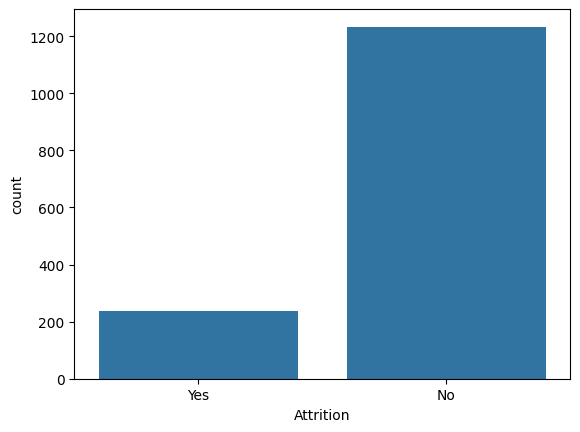

In [23]:
sns.countplot(data = df, x = 'Attrition')
plt.show()

The dataset is highly imbalanced, most employees stayed with the company, while only a minority left.

### 1. Which department has the highest employee attrition?

## Department vs Attrition

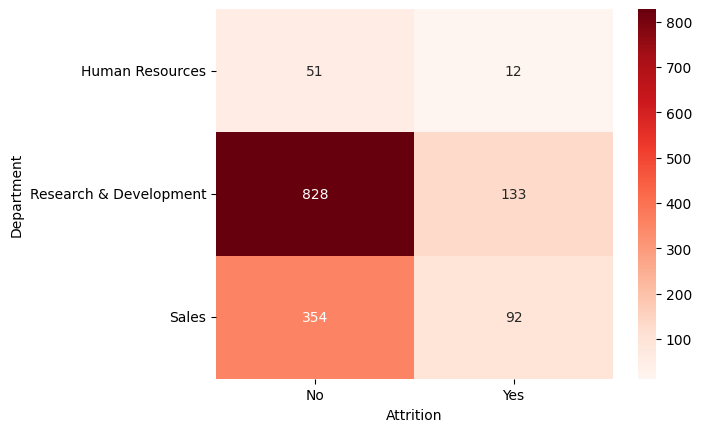

In [29]:
cross = pd.crosstab(df['Department'],df['Attrition'])
sns.heatmap(cross,annot = True,fmt= "d", cmap = "Reds")
plt.show()

The Sales department has the highest attrition rate, followed by Human Resources, while Research & Development has the lowest attrition rate.

### 2. Does overtime increase the likelihood of employees leaving?

## Overtime vs Attrition

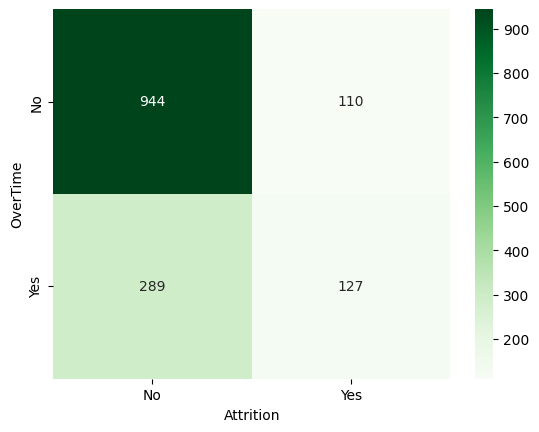

In [45]:
sns.heatmap(pd.crosstab(df['OverTime'],df['Attrition']),annot = True,fmt = "d",cmap = "Greens")
plt.show()

Yes, employess who work overtime are far more likely to leave. Among those who do Overtime, a much larger share left(127 out of 416) compared to those who don't (110 out of 1054),showing overtime is a strong driver of attrition.

### 3. Is salary related to attrition?

## Salary Distribution by attrition

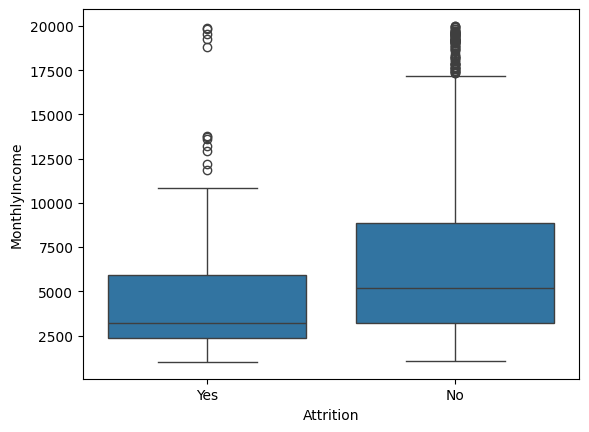

In [49]:
sns.boxplot( x = 'Attrition',y = 'MonthlyIncome', data = df)
plt.show()

Yes, lower salary is linked to higher attrition, Employees who left have a noticeably lower median monthly income than those who stayed, suggesting pay is a contributing pay factor to attrition.

### 4. Which age group leaves the most?

## Age Distribution with attrition

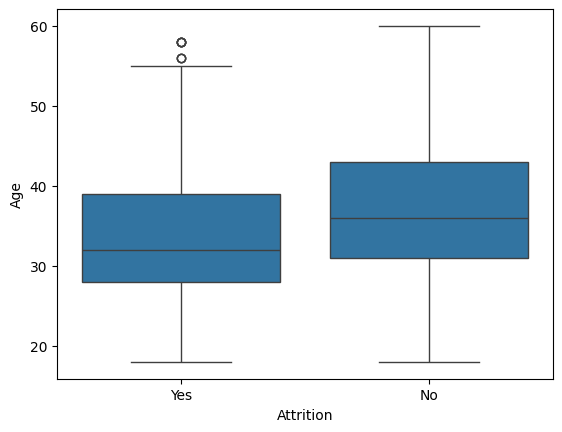

In [52]:
sns.boxplot(x = 'Attrition', y = 'Age',data = df)
plt.show()

Younger employees are more likely to leave. Those who left have a lower median age compared to those who stayed , showing attrition is more common among younger employees.

### 5. Does job satisfaction affect attrition?

## Job Satisfaction vs Attrition

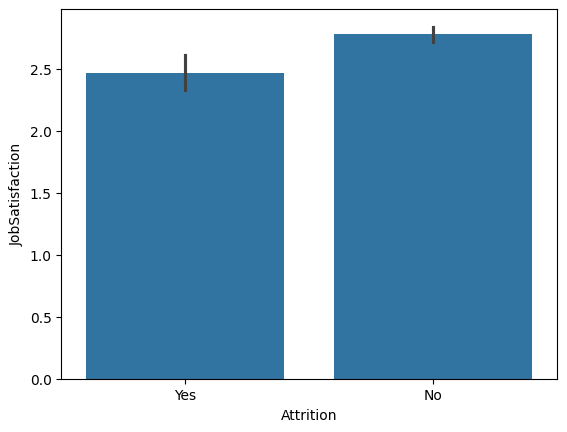

In [54]:
sns.barplot(x = 'Attrition', y = 'JobSatisfaction',data = df)
plt.show()

Job satisfaction as only a very small effect on attrition. Employees who left have slightly lower average job satisfaction score than those who stayed, but the difference is minor,suggesting it's a weak factor compared to others like overtime or income.

### 6. Does environment satisfaction affect attrition?

## Environmental Satisfaction vs Attrition

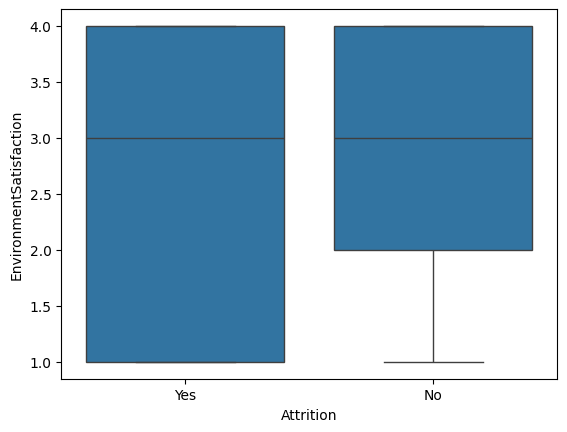

In [59]:
sns.boxplot(x = 'Attrition', y = 'EnvironmentSatisfaction',data = df)
plt.show()

Environment satisfaction has little effect on attrition. Both meadian groups have the same median score, with employees who left showing a slightly wider/lower spread - but overall the difference between those who stayed and left is minimal.

### 7. Does longer tenure reduce attrition?

## Tenure Distribution

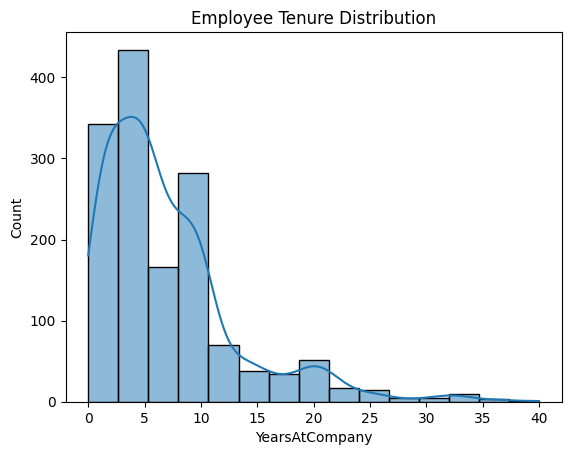

In [61]:
sns.histplot(df['YearsAtCompany'], bins=15,kde = True)
plt.title('Employee Tenure Distribution')
plt.show()

## Years at Company vs Attrition

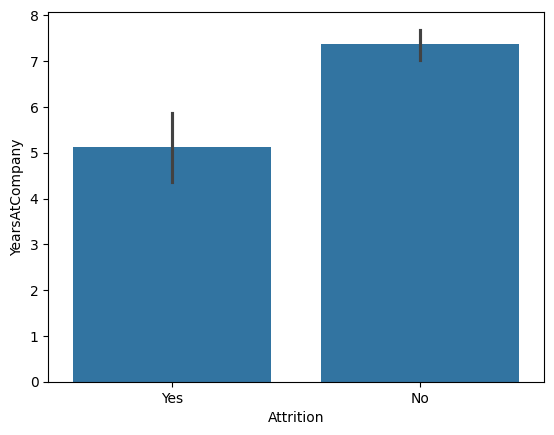

In [62]:
sns.barplot(x = 'Attrition', y = 'YearsAtCompany',data = df)
plt.show()

Yes, longer tenure reduces attrition. Employees who left have spent fewer years at the company on average compared to those who stayed, confirming that newer employees are at higher risk of leaving.

### 8. Which job roles experience the highest attrition? 

## Job Roles vs Attrition 

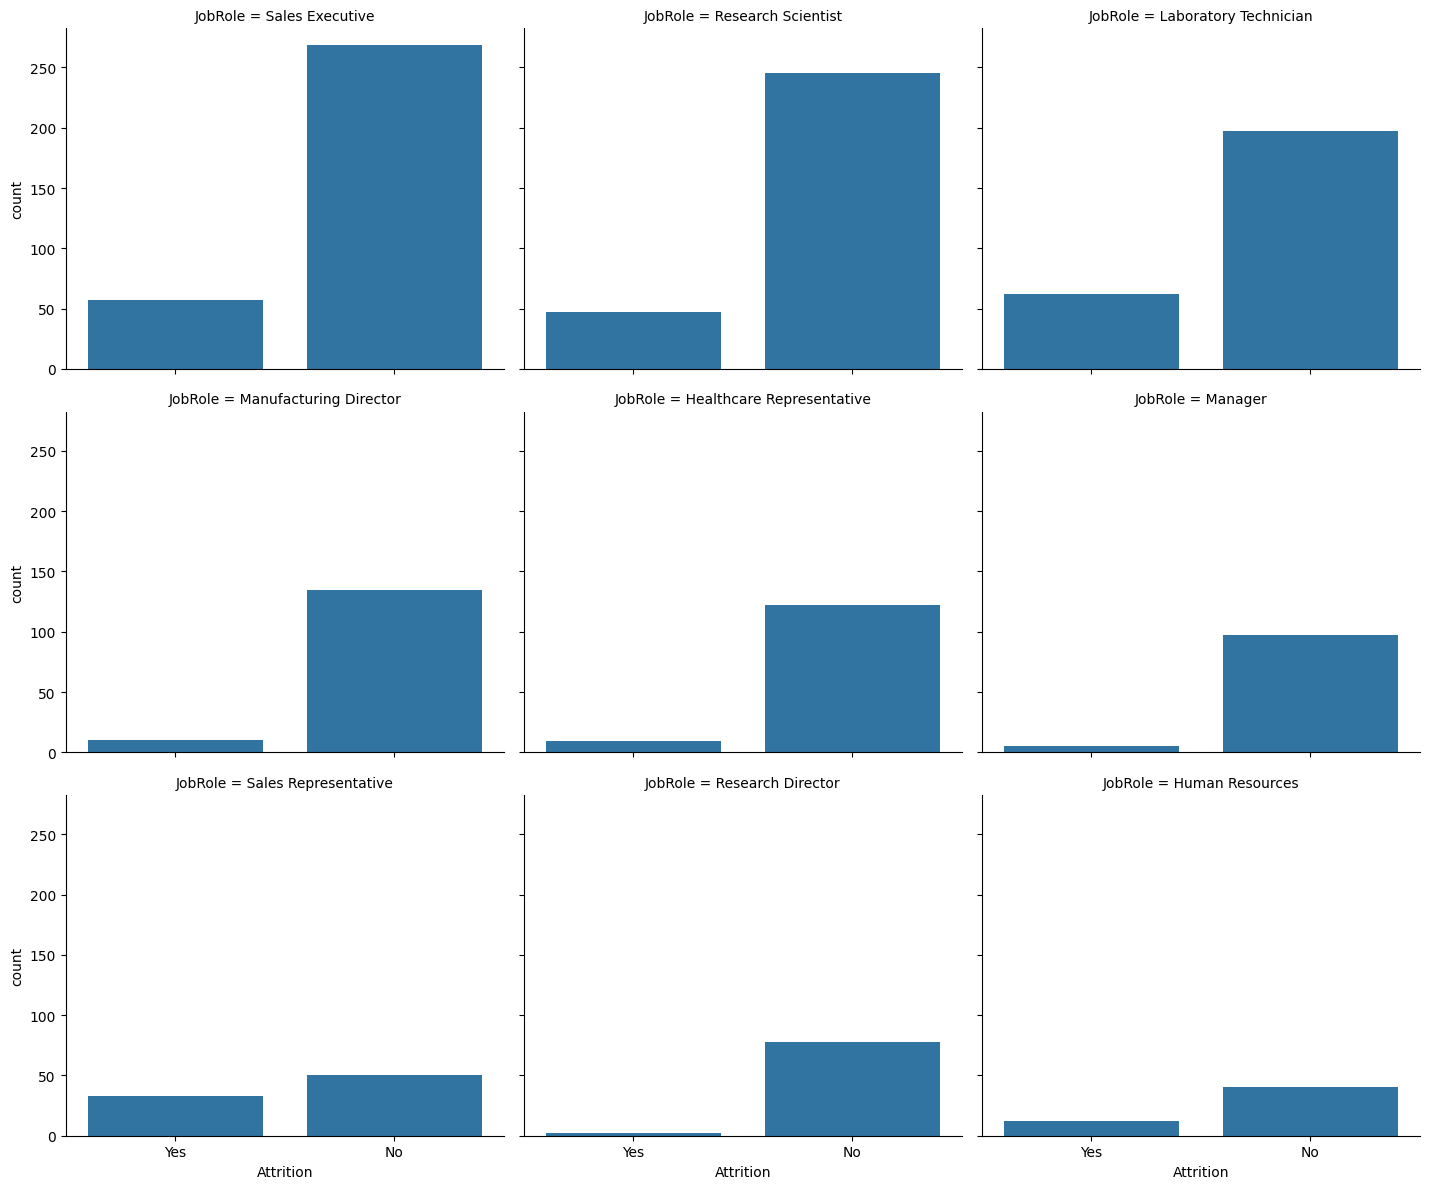

In [81]:
sns.catplot(data=df, x="Attrition", col="JobRole", kind="count",col_wrap = 3, height=4, aspect=1.2)
plt.show()

Sales Representive have the highest attrition rate, followed by laboratory technicians and sales executives- roles in sales and technical/lab poositions show noticeably more turonover than managerial ot director-level roles which have very low attrition.

### 9. Does marital status influence attrition?

## Marital Status vs Attrition

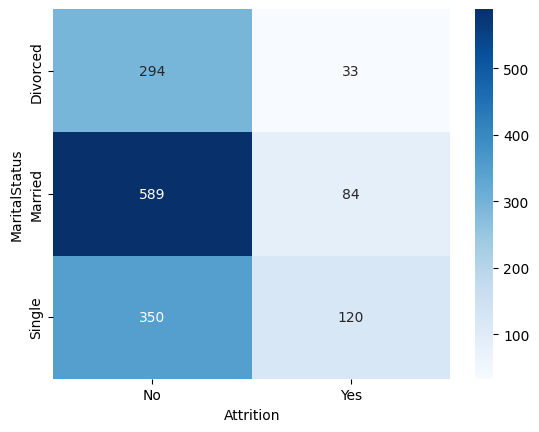

In [90]:
sns.heatmap(pd.crosstab(df['MaritalStatus'],df['Attrition']),annot = True,fmt = "d",cmap = "Blues")
plt.show()

Yes, marital status influences attrition. Single employees have the highest attrition rate, much higher than divorced employees, suggesting single employees are more likely to leave than those who are divorced.

### 10. Which combinations of factors are most associated with employees leaving?

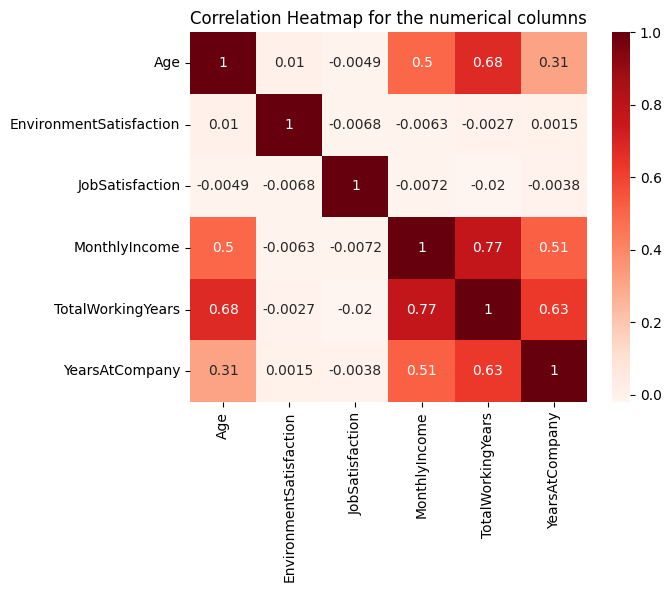

In [102]:
sns.heatmap(corr,annot = True,cmap = "Reds")
plt.title("Correlation Heatmap for the numerical columns")
plt.show()

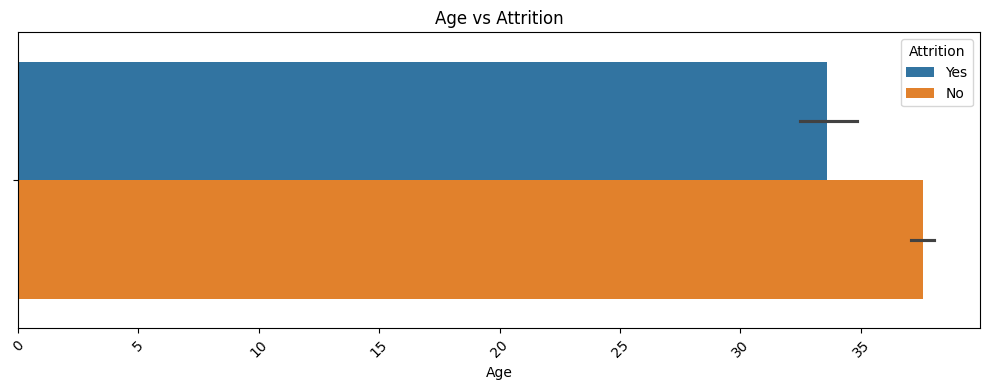

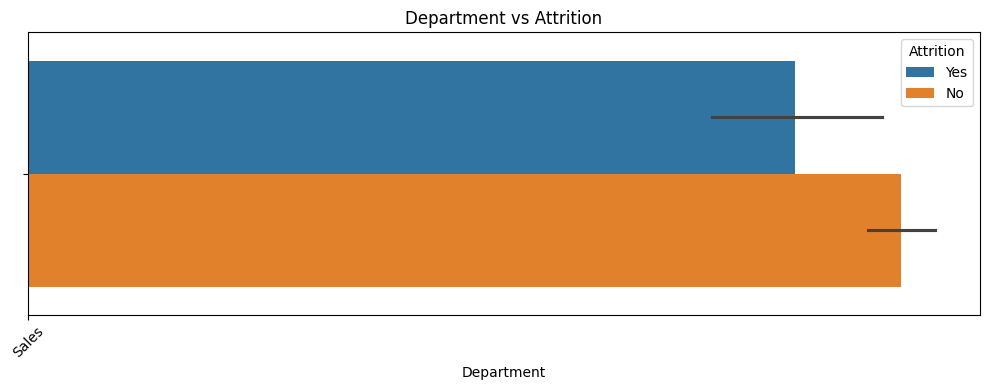

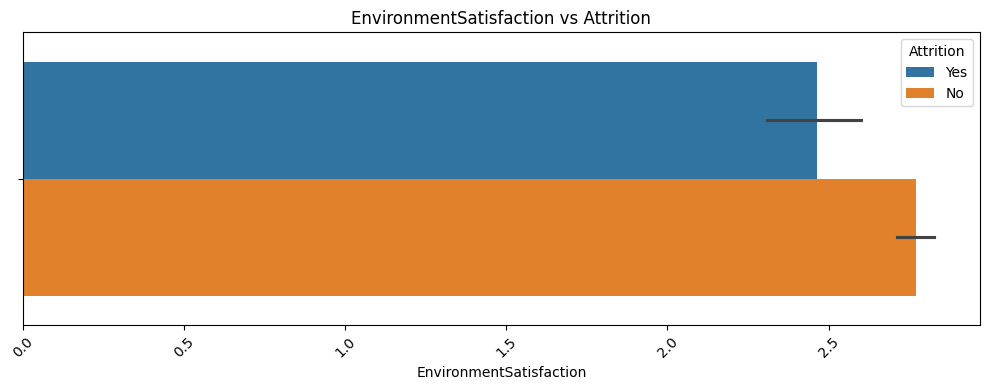

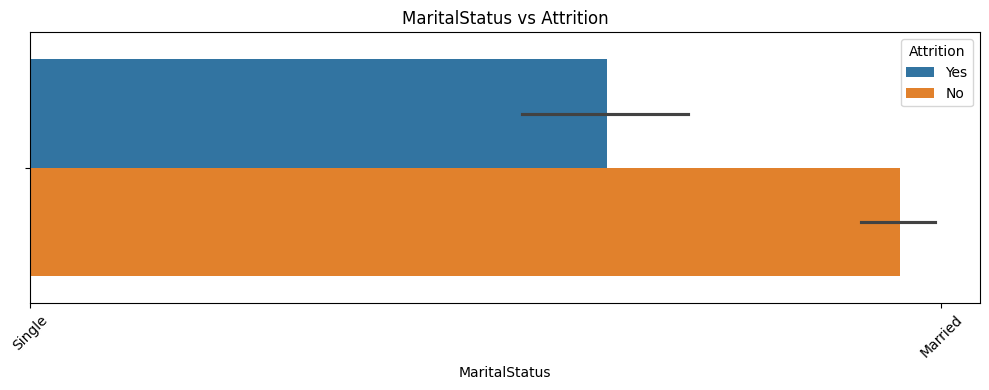

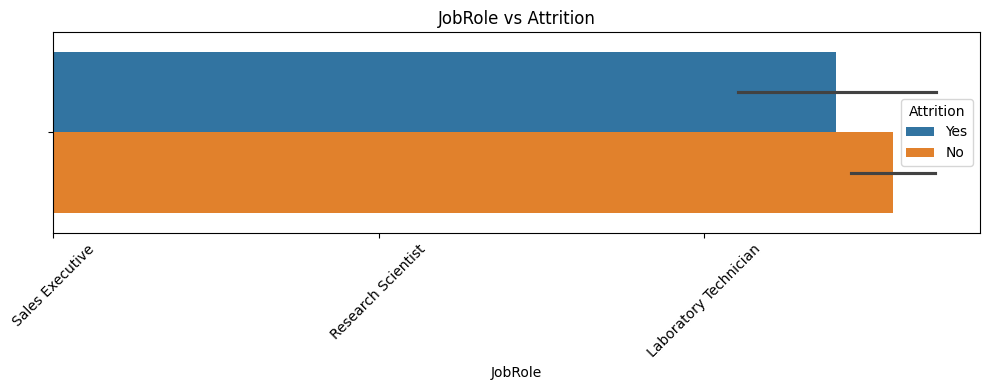

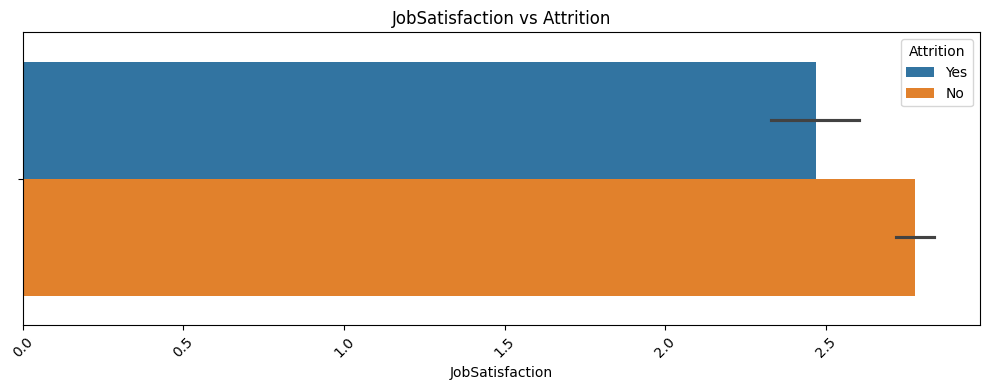

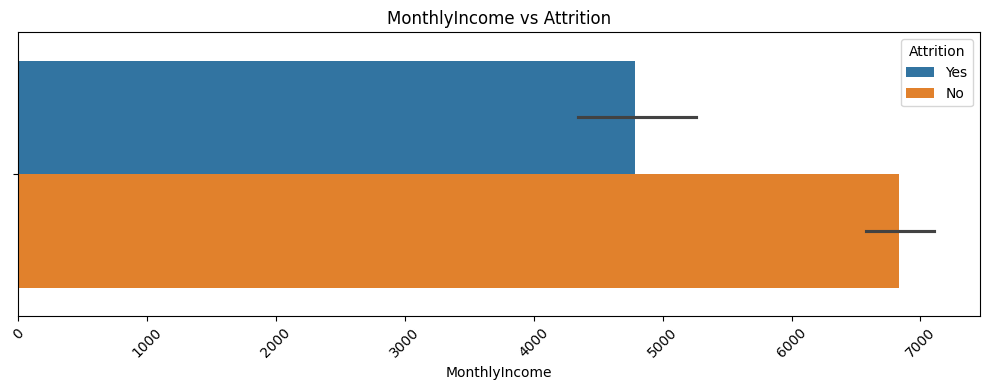

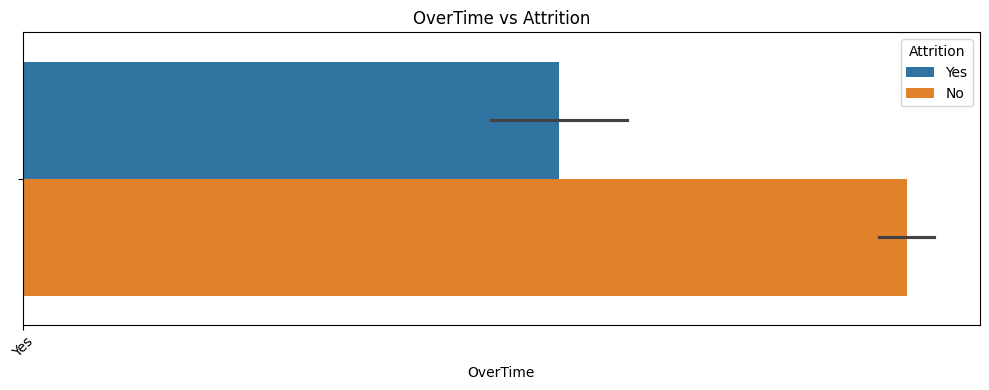

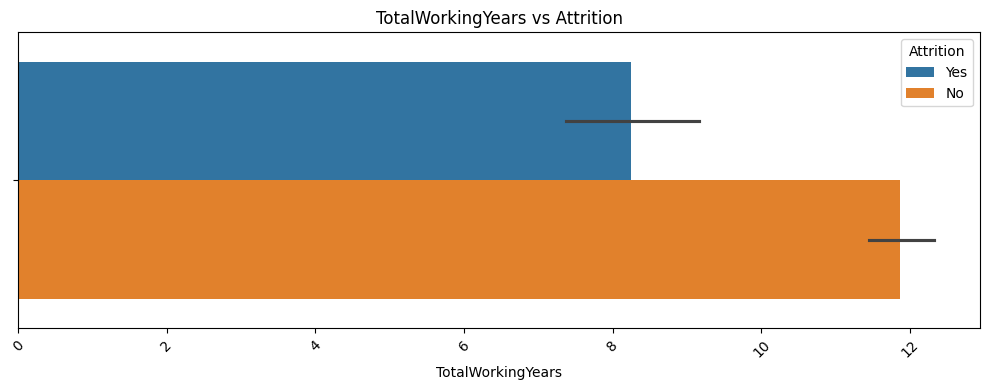

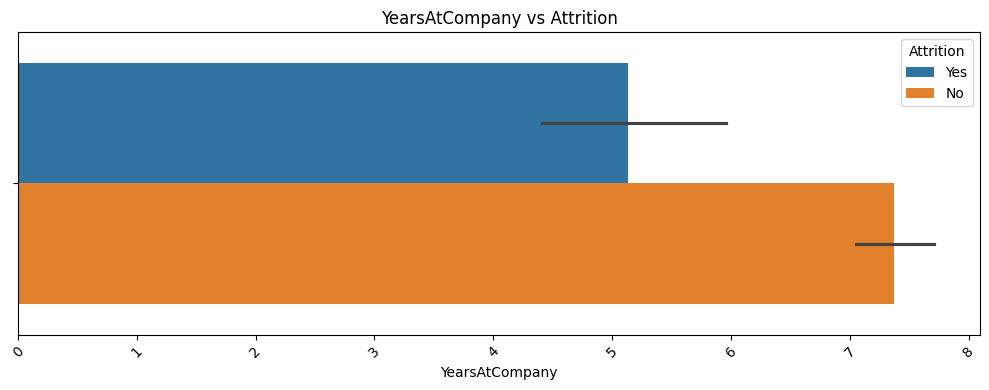

In [110]:
for col in df:
    if col != 'Attrition':
        plt.figure(figsize = (10,4))
        sns.barplot(data = df,x = col,hue = 'Attrition')
        plt.xticks(rotation = 45)
        plt.title(f"{col} vs Attrition")
        plt.tight_layout() 
        plt.show()

Attrition is highest among younger, single employees who work overtime and report low job/environment satisfaction. Lower income and shorter tenure further increase the likelihood of leaving.

# Overall Conclusion

This analysis explored the key factors influencing employee attrition within the company. While most employees remain with the organization, several patterns emerge among those who leave.

The findings show that employees who work overtime are significantly more likely to leave, making overtime one of the strongest indicators of attrition. Lower monthly income is also associated with higher attrition, suggesting that compensation plays an important role in employee retention.

Attrition is more common among younger employees and those with fewer years at the company, indicating that newer employees are at greater risk of leaving. Single employees also experience higher attrition than married or divorced employees.

From a departmental perspective, Sales experiences the highest attrition, while Sales Representatives, Laboratory Technicians, and Sales Executives are the job roles with the greatest employee turnover.

Although job satisfaction and environment satisfaction show some relationship with attrition, their impact appears weaker than overtime, salary, and tenure.

# Business Recommendations
Reduce excessive overtime by improving workload distribution.
Strengthen onboarding and mentoring programs for new employees.
Review compensation and career growth opportunities, especially for lower paid employees.
Focus retention strategies on the Sales department and high-turnover job roles.
Conduct regular employee satisfaction surveys to identify issues before employees decide to leave.

# Final Takeaway
Employee attrition is driven by a combination of workload, compensation, experience, and personal factors rather than a single cause. Organizations can reduce turnover by improving work-life balance, offering competitive salaries, supporting early-career employees, and implementing targeted retention strategies for high-risk departments and job roles.

In [111]:
df.to_csv("employee_hr_cleaned.csv", index=False)